<a href="https://colab.research.google.com/github/codeyson/CPE-313/blob/main/Hands_On_Activity_7_2_%7C_CNN_Architectures_from_Scratch_and_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
dataset = pd.read_csv("/content/drive/MyDrive/TIP Files/32Sx/CPE 313 (Deep Learning with Python)/Hands-On-Activity 7.2 | CNN Architectures from Scratch and Transfer Learning/FastAI_ImageNet_v2/Training.csv")

In [5]:
dataset.head(5)

,path,Label
0,train/cassette_player/n02979186_9036.JPEG,cassette_player
1,train/cassette_player/n02979186_11957.JPEG,cassette_player
2,train/cassette_player/n02979186_9715.JPEG,cassette_player
3,train/cassette_player/n02979186_21736.JPEG,cassette_player
4,train/cassette_player/ILSVRC2012_val_00046953....,cassette_player


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from itertools import cycle
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from tqdm import tqdm

cudnn.benchmark = True
plt.ion()   # interactive mode

## Data Transform

In [7]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(128),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(140),
        transforms.CenterCrop(128),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/TIP Files/32Sx/CPE 313 (Deep Learning with Python)/Hands-On-Activity 7.2 | CNN Architectures from Scratch and Transfer Learning/FastAI_ImageNet_v2'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

from torch.utils.data import random_split

train_dataset = image_datasets['train']
val_dataset = image_datasets['val']

train_size = len(train_dataset) // 2
val_size = len(val_dataset) // 2

train_subset, _ = random_split(
    train_dataset,
    [train_size, len(train_dataset) - train_size]
)

val_subset, _ = random_split(
    val_dataset,
    [val_size, len(val_dataset) - val_size]
)


dataloaders = {'train': torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True,num_workers=0),
               'val':  torch.utils.data.DataLoader(val_subset, batch_size=32, shuffle=True, num_workers=0)
              }
dataset_sizes = {'train': len(train_subset),
                 'val': len(val_subset)
}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [8]:
print("Full train:", len(image_datasets['train']))
print("Full val:", len(image_datasets['val']))

print("Used train:", len(train_subset))
print("Used val:", len(val_subset))

Full train: 9469
Full val: 3925
Used train: 4734
Used val: 1962


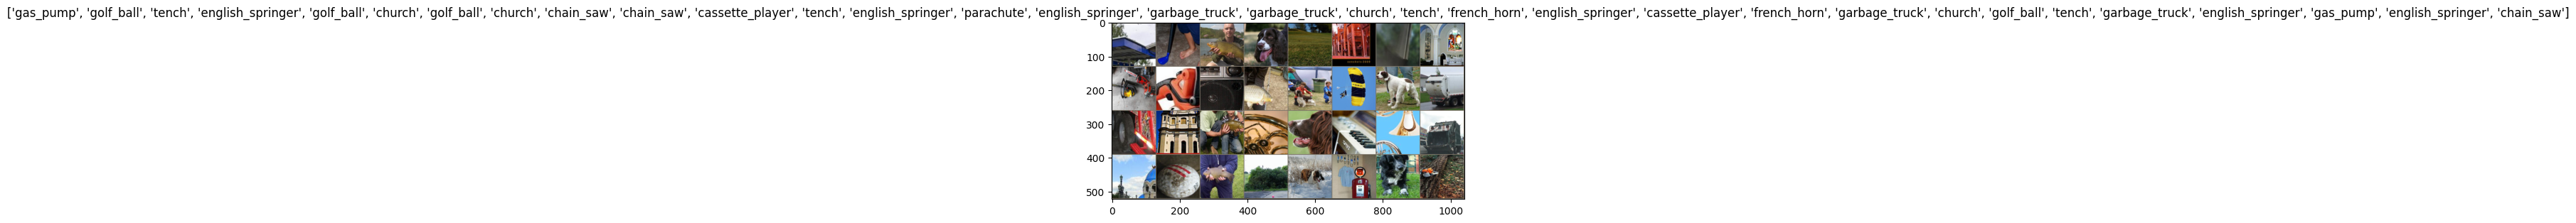

In [9]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [10]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # dictionary to store scores for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                loop = tqdm(dataloaders[phase], desc=phase)

                for inputs, labels in loop:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)

                        # FIX for scratch models that output (B,C,1,1)
                        if outputs.dim() == 4:
                            outputs = outputs.squeeze()

                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                    # show live loss in tqdm
                    loop.set_postfix(loss=loss.item())

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Store metrics in history
                history[f'{phase}_loss'].append(epoch_loss)
                history[f'{phase}_acc'].append(epoch_acc.item())

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))

    return model, history

In [11]:
def predictions(model, dataloader):
    model.eval()
    all_pred = []
    all_label = []

    with torch.no_grad():
        for input, label in dataloader:
            input = input.to(device)
            output = model(input)
            _, pred = torch.max(output, 1)
            all_pred.extend(pred.cpu().numpy())
            all_label.extend(label.cpu().numpy())

    return np.array(all_label), np.array(all_pred)

In [12]:
def y_probs(model, dataloader):
    model.eval()
    all_prob = []
    all_label = []

    with torch.no_grad():
        for input, label in dataloader:
            input = input.to(device)
            output = model(input)
            prob = F.softmax(output, dim=1)
            all_prob.extend(prob.cpu().numpy())
            all_label.extend(label.cpu().numpy())

    return np.array(all_label), np.array(all_prob)

## VGG16 Scratch Archi

In [13]:
import torch
import torch.nn as nn

class VGG16Scratch(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16Scratch, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2,2),

            # Block 2
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2,2),

            # Block 3
            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2,2),

            # Block 4
            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2,2),

            # Block 5
            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2,2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512),
            nn.ReLU(True),
            nn.Linear(512,512),
            nn.ReLU(True),
            nn.Linear(512, num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Training

In [14]:
model_ft = VGG16Scratch(num_classes=10)
#n_features = model_ft.classifier[0].in_features
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.5)

In [15]:
model_ft, hist = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------


train: 100%|██████████| 148/148 [25:20<00:00, 10.27s/it, loss=2.22]


train Loss: 2.2731 Acc: 0.1411


val: 100%|██████████| 62/62 [11:34<00:00, 11.19s/it, loss=2.16]


val Loss: 2.1595 Acc: 0.1534

Epoch 1/24
----------


...

val Loss: 1.0059 Acc: 0.6677

Epoch 24/24
----------


train: 100%|██████████| 148/148 [00:36<00:00,  4.01it/s, loss=1.03]


train Loss: 1.1982 Acc: 0.5963


val: 100%|██████████| 62/62 [00:12<00:00,  4.89it/s, loss=1.33]

val Loss: 1.0095 Acc: 0.6718

Training complete in 56m 57s
Best val Acc: 0.671764


### Plotting

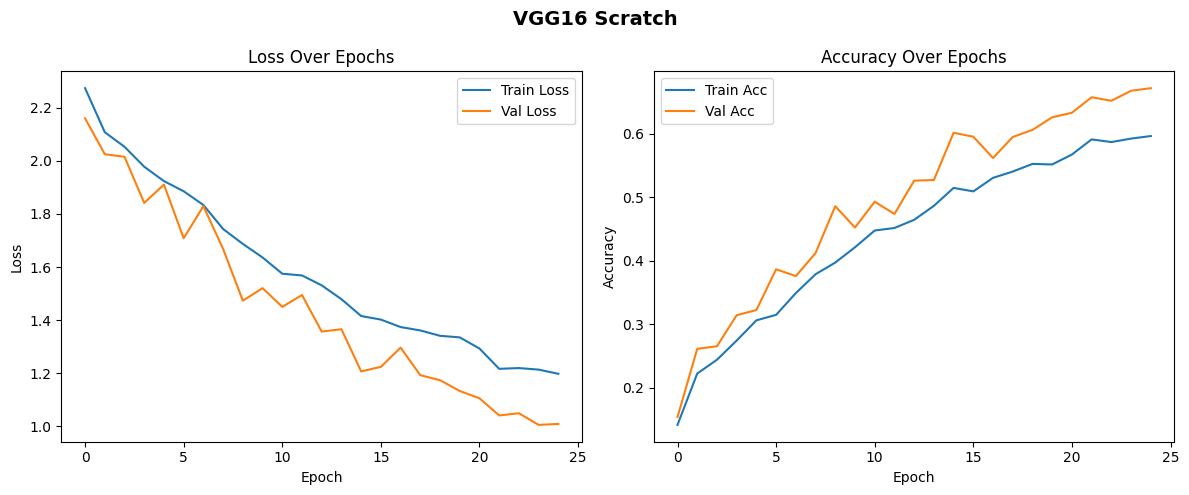

In [16]:
#VGG16 Scratch - Loss & Accuracy

plt.figure(figsize=(12, 5))
plt.suptitle('VGG16 Scratch', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(hist['train_loss'], label='Train Loss')
plt.plot(hist['val_loss'],   label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['train_acc'], label='Train Acc')
plt.plot(hist['val_acc'],   label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report — VGG16 Scratch
(Sensitivity = Recall for each class)

                  precision    recall  f1-score   support

 cassette_player       0.68      0.61      0.65       179
       chain_saw       0.51      0.28      0.36       192
          church       0.74      0.73      0.74       213
english_springer       0.60      0.81      0.69       195
     french_horn       0.79      0.62      0.70       193
   garbage_truck       0.59      0.84      0.69       188
        gas_pump       0.66      0.74      0.70       216
       golf_ball       0.67      0.53      0.59       189
       parachute       0.86      0.73      0.79       213
           tench       0.65      0.80      0.72       184

        accuracy                           0.67      1962
       macro avg       0.67      0.67      0.66      1962
    weighted avg       0.68      0.67      0.66      1962



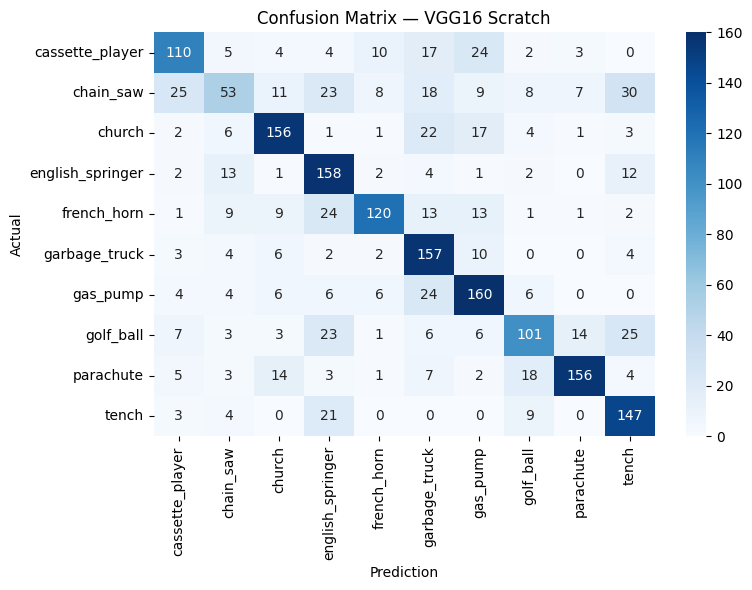

In [17]:
#VGG16 Scratch - Confusion Matrix & Classification Report
y_true_vgg_scratch, y_pred_vgg_scratch = predictions(model_ft, dataloaders['val'])

print("Classification Report — VGG16 Scratch")
print("(Sensitivity = Recall for each class)\n")
print(classification_report(y_true_vgg_scratch, y_pred_vgg_scratch, target_names=class_names))

cm = confusion_matrix(y_true_vgg_scratch, y_pred_vgg_scratch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix — VGG16 Scratch')
plt.tight_layout()
plt.show()

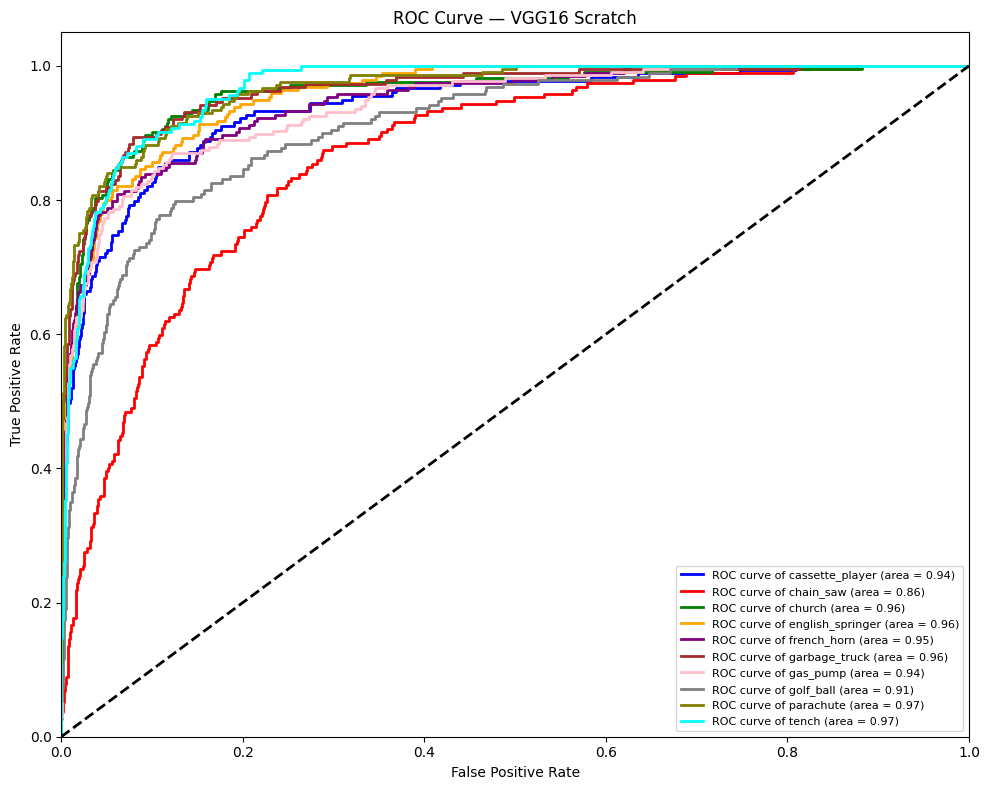

In [18]:
# VGG16 Scratch - ROC AUC
y_test_vgg_scratch, y_score_vgg_scratch = y_probs(model_ft, dataloaders['val'])

n_classes = len(class_names)
y_bin     = label_binarize(y_test_vgg_scratch, classes=[i for i in range(n_classes)])
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score_vgg_scratch[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'orange', 'purple',
                'brown', 'pink', 'gray', 'olive', 'cyan'])

plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — VGG16 Scratch')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

###  Interpretation

The accuracy and loss pver epoch for scratch looks good. If I let it train for more epoch it will return a better result as based on the graph it keeps increasing. Based on the confusion matrix, it can classify the majority of values but sometimes in still makes mistakes. In the ROC curve, it reveals that golf_ball and chain_saw is can't be classify by the model well.

## VGG 16 (Pre-trained)

In [19]:
from torchvision import models
import torch.nn as nn

In [20]:
model_ftvgg = models.vgg16(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 75.0MB/s]


In [21]:
num_classes = len(class_names)

model_ftvgg.classifier[6] = nn.Linear(4096, num_classes)

In [22]:
model_ftvgg = model_ftvgg.to(device)
for param in model_ftvgg.features.parameters():
    param.requires_grad = False

In [23]:
criterion_vgg = nn.CrossEntropyLoss()

optimizer_ftvgg = optim.SGD(model_ftvgg.parameters(), lr=0.001, momentum=0.9)

In [24]:
exp_lr_scheduler_vgg = lr_scheduler.StepLR(optimizer_ftvgg, step_size=7, gamma=0.1)

In [25]:
model_ftvgg, hist_ftvgg = train_model(model_ftvgg, criterion_vgg, optimizer_ftvgg, exp_lr_scheduler_vgg,
                                      num_epochs=10)

Epoch 0/9
----------


train: 100%|██████████| 148/148 [00:38<00:00,  3.85it/s, loss=0.233]


train Loss: 0.3669 Acc: 0.8885


val: 100%|██████████| 62/62 [00:15<00:00,  4.01it/s, loss=0.0794]


val Loss: 0.0874 Acc: 0.9745

Epoch 1/9
----------


...

val Loss: 0.0724 Acc: 0.9801

Epoch 9/9
----------


train: 100%|██████████| 148/148 [00:36<00:00,  4.05it/s, loss=0.114]


train Loss: 0.1350 Acc: 0.9571


val: 100%|██████████| 62/62 [00:15<00:00,  4.08it/s, loss=0.04]


val Loss: 0.0718 Acc: 0.9796

Training complete in 9m 8s
Best val Acc: 0.980122


### Plotting

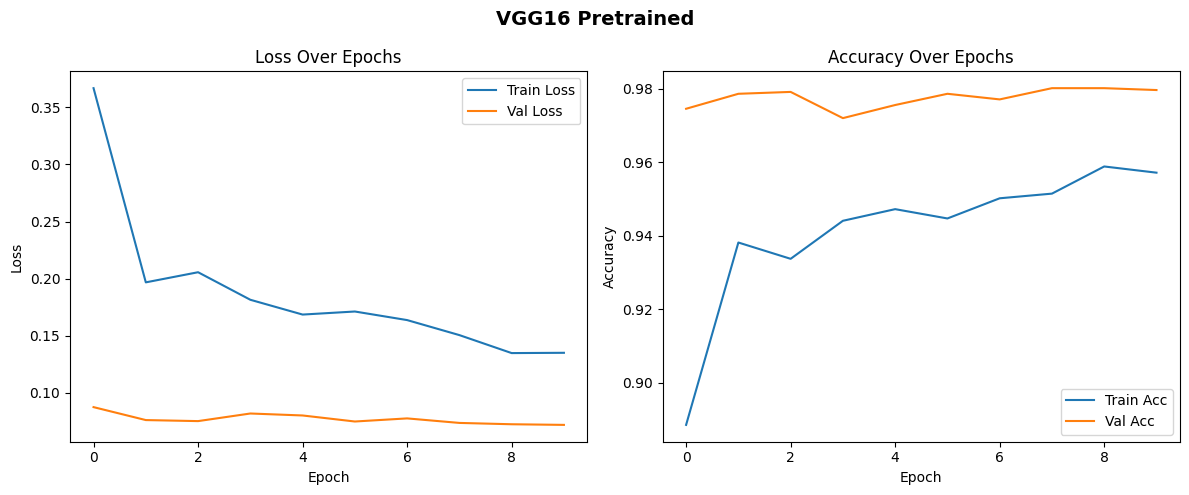

In [26]:
# VGG16 Pretrained - Loss & Accuracy

plt.figure(figsize=(12, 5))
plt.suptitle('VGG16 Pretrained', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(hist_ftvgg['train_loss'], label='Train Loss')
plt.plot(hist_ftvgg['val_loss'],   label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_ftvgg['train_acc'], label='Train Acc')
plt.plot(hist_ftvgg['val_acc'],   label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report — VGG16 Pretrained
(Sensitivity = Recall for each class)

                  precision    recall  f1-score   support

 cassette_player       0.98      0.98      0.98       179
       chain_saw       0.97      0.95      0.96       192
          church       0.99      0.99      0.99       213
english_springer       0.98      0.99      0.99       195
     french_horn       0.97      0.98      0.98       193
   garbage_truck       0.96      0.99      0.97       188
        gas_pump       0.97      0.94      0.96       216
       golf_ball       0.99      0.99      0.99       189
       parachute       0.99      0.99      0.99       213
           tench       1.00      1.00      1.00       184

        accuracy                           0.98      1962
       macro avg       0.98      0.98      0.98      1962
    weighted avg       0.98      0.98      0.98      1962



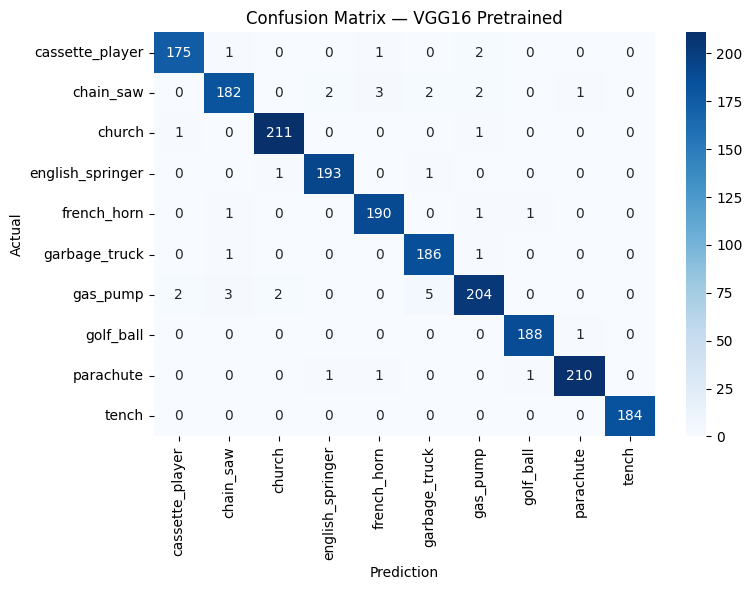

In [27]:
# VGG16 Pretrained - Confusion Matrix & Classification Report

y_true_vgg_pre, y_pred_vgg_pre = predictions(model_ftvgg, dataloaders['val'])

print("Classification Report — VGG16 Pretrained")
print("(Sensitivity = Recall for each class)\n")
print(classification_report(y_true_vgg_pre, y_pred_vgg_pre, target_names=class_names))

cm = confusion_matrix(y_true_vgg_pre, y_pred_vgg_pre)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix — VGG16 Pretrained')
plt.tight_layout()
plt.show()

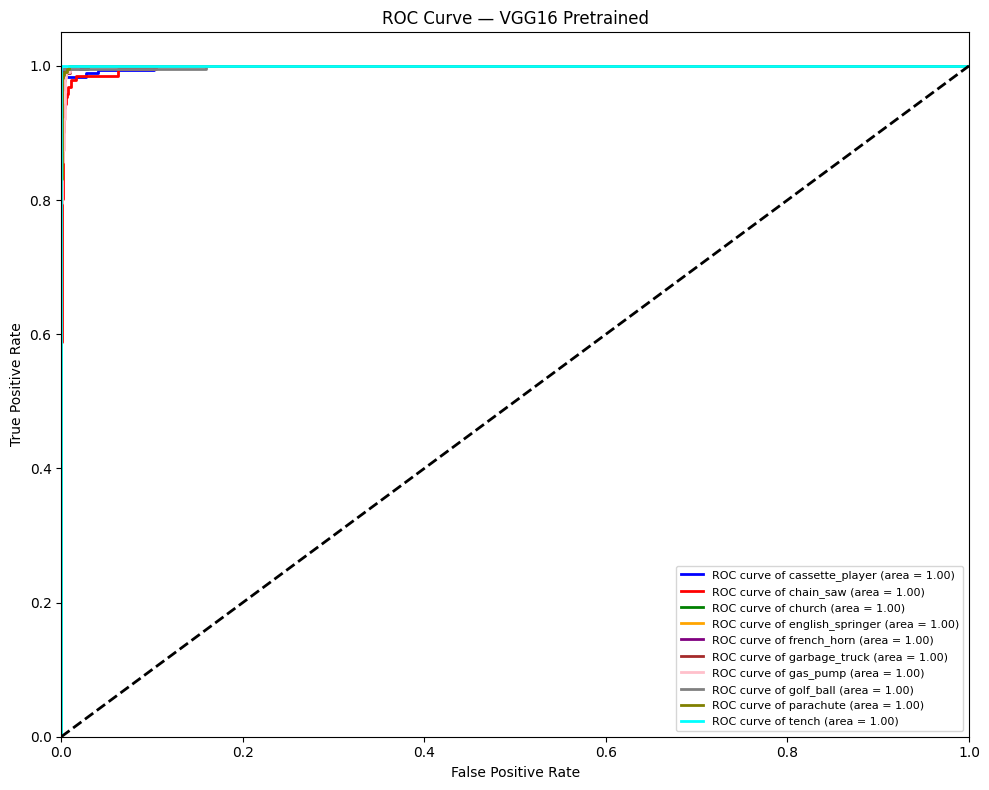

In [28]:
# VGG16 Pretrained - ROC AUC
y_test_vgg_pre, y_score_vgg_pre = y_probs(model_ftvgg, dataloaders['val'])

n_classes = len(class_names)
y_bin     = label_binarize(y_test_vgg_pre, classes=[i for i in range(n_classes)])
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score_vgg_pre[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'orange', 'purple',
                'brown', 'pink', 'gray', 'olive', 'cyan'])

plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — VGG16 Pretrained')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretaion

Overall for the pretrained vgg16 is looking good. I would say it can classify all the classes pretty well compared to scratch vgg16.

## MobileNetv2 Scratch Archi

In [33]:
import torch
import torch.nn as nn
from torchinfo import summary
from collections import OrderedDict

# Depthwise Convolution Module
class DepthWise_Conv(nn.Module):
    def __init__(self, in_fts, stride=(1,1)) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_fts, in_fts, kernel_size=(3,3), stride=stride, padding=(1,1), groups=in_fts, bias=False),
            nn.BatchNorm2d(in_fts),
            nn.ReLU6(inplace=True)
        )

    def forward(self, input_image):
        x = self.conv(input_image)
        return x

# PointWise Convolution Module
class Pointwise_Conv(nn.Module):
    def __init__(self, in_fts, out_fts) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_fts, out_fts, kernel_size=(1,1), bias=False),
            nn.BatchNorm2d(out_fts)
        )
    def forward(self, input_image):
        x = self.conv(input_image)
        return x

# Bottleneck Layer when Stride is 1
class NetForStrideOne(nn.Module):
    def __init__(self, in_fts, out_fts, expansion) -> None:
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_fts, expansion*in_fts, kernel_size=(1,1), bias=False),
            nn.BatchNorm2d(expansion*in_fts),
            nn.ReLU6(inplace=True)
        )
        self.dw = DepthWise_Conv(expansion*in_fts)
        self.pw = Pointwise_Conv(expansion*in_fts, out_fts)

        self.in_fts = in_fts
        self.out_fts = out_fts
        self.expansion = expansion

    def forward(self, input_image):
        if self.expansion == 1:
            x = self.dw(input_image)
            x = self.pw(x)
        else:
            x = self.conv1(input_image)
            x = self.dw(x)
            x = self.pw(x)

        # If input channel and output channel are same, then perform add
        # residual part
        if self.in_fts == self.out_fts:
            x = input_image + x

        return x

# Bottleneck layer when Stride is 2
class NetForStrideTwo(nn.Module):
    def __init__(self, in_fts, out_fts, expansion) -> None:
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_fts, expansion*in_fts, kernel_size=(1,1), bias=False),
            nn.BatchNorm2d(expansion*in_fts),
            nn.ReLU6(inplace=True)
        )
        self.dw = DepthWise_Conv(expansion*in_fts, stride=(2,2))
        self.pw = Pointwise_Conv(expansion*in_fts, out_fts)

        self.expansion = expansion

    def forward(self, input_image):
        if self.expansion == 1:
            x = self.dw(input_image)
            x = self.pw(x)
        else:
            x = self.conv1(input_image)
            x = self.dw(x)
            x = self.pw(x)

        return x

# MobileNetV2 architecture
class MyMobileNet_v2(nn.Module):
    def __init__(self, bottleneckLayerDetails, in_fts=3, numClasses=1000, width_multiplier=1) -> None:
        super().__init__()
        self.bottleneckLayerDetails = bottleneckLayerDetails
        self.width_multiplier = width_multiplier

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_fts, round(width_multiplier*32), kernel_size=(3,3), stride=(2,2), padding=(1,1), bias=False),
            nn.BatchNorm2d(round(width_multiplier*32)),
            nn.ReLU6(inplace=True)
        )
        self.in_fts = round(width_multiplier*32)

        # Defined bottleneck layer as per Table 2
        self.layerConstructed = self.constructLayer()

        # Top layers after bottleneck
        self.feature = nn.Sequential(
            nn.Conv2d(self.in_fts, round(width_multiplier*1280), kernel_size=(1,1), bias=False),
            nn.BatchNorm2d(round(width_multiplier*1280)),
            nn.ReLU6(inplace=True)
        )

        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1,1))

        self.outputLayer = nn.Sequential(
            nn.Dropout2d(),
            nn.Conv2d(round(width_multiplier*1280), numClasses, kernel_size=(1,1)),
        )

    def forward(self, input_image):
        x = self.conv1(input_image)
        x = self.layerConstructed(x)
        x = self.feature(x)
        x = self.avgpool(x)
        x = self.outputLayer(x)
        x = torch.flatten(x, 1)
        return x

    # Defined function to construct the layer based on bottleneck layer defined in Table 2
    def constructLayer(self):
        itemIndex = 0
        block = OrderedDict()
        # iterating the defined layer details
        for lItem in self.bottleneckLayerDetails:
            # each items assigned corresponding values
            t, out_fts, n, stride = lItem
            # If width multipler is mentioned then perform this line
            out_fts = round(self.width_multiplier*out_fts)
            # for stride value 1
            if stride == 1:
                # constructedd the NetForStrideOne module by n times
                for nItem in range(n):
                    block[str(itemIndex)+"_"+str(nItem)] = NetForStrideOne(self.in_fts, out_fts, t)
                    self.in_fts = out_fts
            # for stride value 2
            elif stride == 2:
                # First layer constructed for NetForStrideTwo module once only
                block[str(itemIndex)+"_"+str(0)] = NetForStrideTwo(self.in_fts, out_fts, t)
                self.in_fts = out_fts
                # Remaining will be NetForStrideOne module (n-1) times
                for nItem in range(1,n):
                    block[str(itemIndex)+"_"+str(nItem)] = NetForStrideOne(self.in_fts, out_fts, t)
            itemIndex += 1

        return nn.Sequential(block)

if __name__ == "__main__":
    # as per research paper
    bottleneckLayerDetails = [
        # (expansion, out_dimension, number_of_times, stride)
            (1,16,1,1),
            (6,24,2,2),
            (6,32,3,2),
            (6,64,4,2),
            (6,96,3,1),
            (6,160,3,2),
            (6,320,1,1)
        ]

    m = MyMobileNet_v2(bottleneckLayerDetails, width_multiplier=1)
    summary(m, (1,3,224,224))

In [34]:
model_mobileNet = MyMobileNet_v2(bottleneckLayerDetails, in_fts=3, numClasses=10, width_multiplier=1)
model_scratch_MB = model_mobileNet.to(device)

In [35]:
criterion_scratch_MB = nn.CrossEntropyLoss()

optimizer_scratch_MB = optim.Adam(model_scratch_MB.parameters(), lr=0.001)

exp_lr_scheduler_scratch_MB = lr_scheduler.StepLR(optimizer_scratch_MB, step_size=7,gamma=0.1)

In [51]:
model_scratch_MB, hist_scratch_MB = train_model(model_scratch_MB, criterion_scratch_MB, optimizer_scratch_MB, exp_lr_scheduler_scratch_MB,
                                                num_epochs=25)

Epoch 0/24
----------


train: 100%|██████████| 148/148 [00:34<00:00,  4.28it/s, loss=1.04]


train Loss: 1.2634 Acc: 0.5788


val: 100%|██████████| 62/62 [00:12<00:00,  5.00it/s, loss=1.45]


val Loss: 1.0596 Acc: 0.6606

Epoch 1/24
----------


...

val Loss: 0.9581 Acc: 0.6978

Epoch 24/24
----------


train: 100%|██████████| 148/148 [00:33<00:00,  4.42it/s, loss=1.25]


train Loss: 1.1526 Acc: 0.6187


val: 100%|██████████| 62/62 [00:12<00:00,  5.06it/s, loss=0.539]

val Loss: 0.9642 Acc: 0.6896

Training complete in 18m 56s
Best val Acc: 0.699286


### Plotting


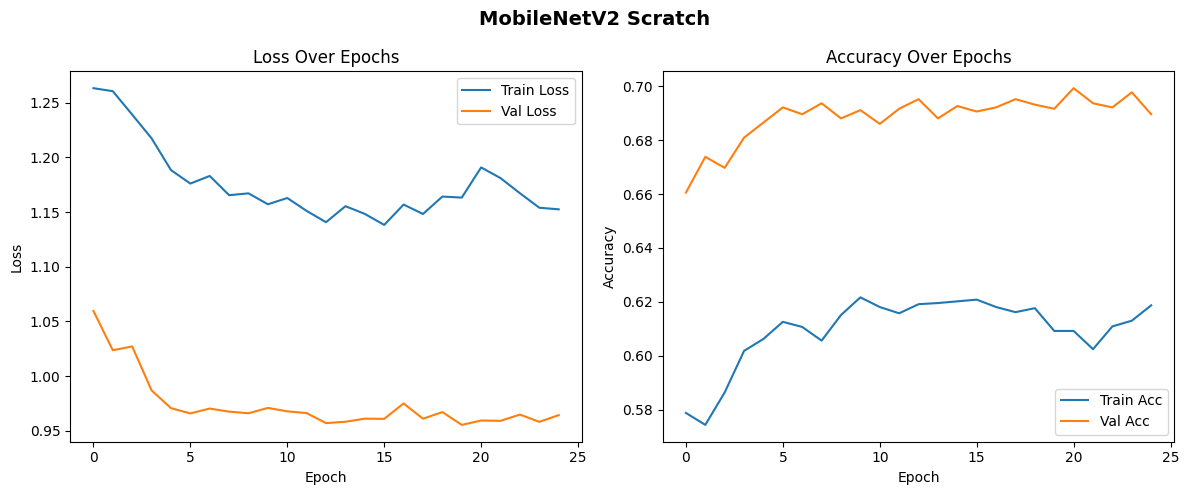

In [52]:
# MobileNetV2 Scratch - Loss & Accuracy

plt.figure(figsize=(12, 5))
plt.suptitle('MobileNetV2 Scratch', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(hist_scratch_MB['train_loss'], label='Train Loss')
plt.plot(hist_scratch_MB['val_loss'],   label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_scratch_MB['train_acc'], label='Train Acc')
plt.plot(hist_scratch_MB['val_acc'],   label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report — MobileNetV2 Scratch
(Sensitivity = Recall for each class)

                  precision    recall  f1-score   support

 cassette_player       0.72      0.65      0.68       179
       chain_saw       0.52      0.35      0.42       192
          church       0.74      0.80      0.77       213
english_springer       0.68      0.79      0.73       195
     french_horn       0.64      0.70      0.67       193
   garbage_truck       0.68      0.80      0.74       188
        gas_pump       0.75      0.67      0.71       216
       golf_ball       0.70      0.62      0.66       189
       parachute       0.86      0.79      0.82       213
           tench       0.65      0.79      0.71       184

        accuracy                           0.70      1962
       macro avg       0.69      0.70      0.69      1962
    weighted avg       0.70      0.70      0.69      1962



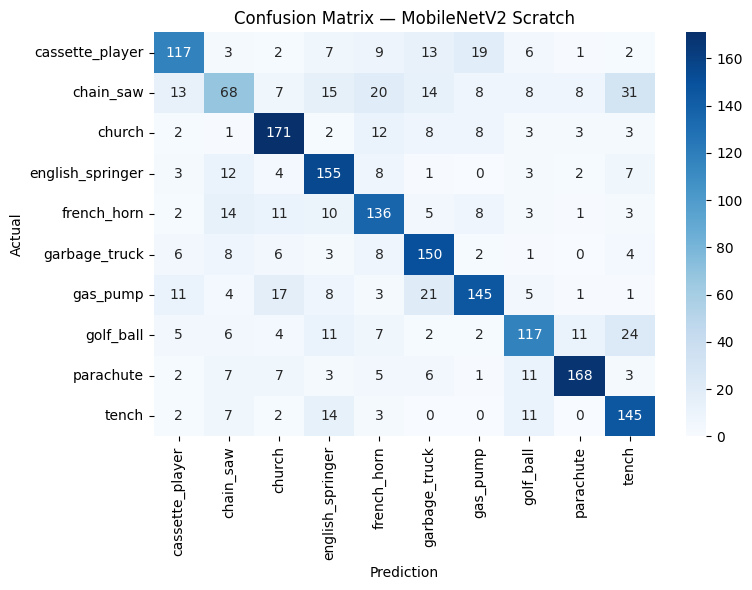

In [53]:
# MobileNetV2 Scratch - Confusion Matrix & Classification Report
y_true_mob_scratch, y_pred_mob_scratch = predictions(model_scratch_MB, dataloaders['val'])

print("Classification Report — MobileNetV2 Scratch")
print("(Sensitivity = Recall for each class)\n")
print(classification_report(y_true_mob_scratch, y_pred_mob_scratch, target_names=class_names))

cm = confusion_matrix(y_true_mob_scratch, y_pred_mob_scratch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix — MobileNetV2 Scratch')
plt.tight_layout()
plt.show()


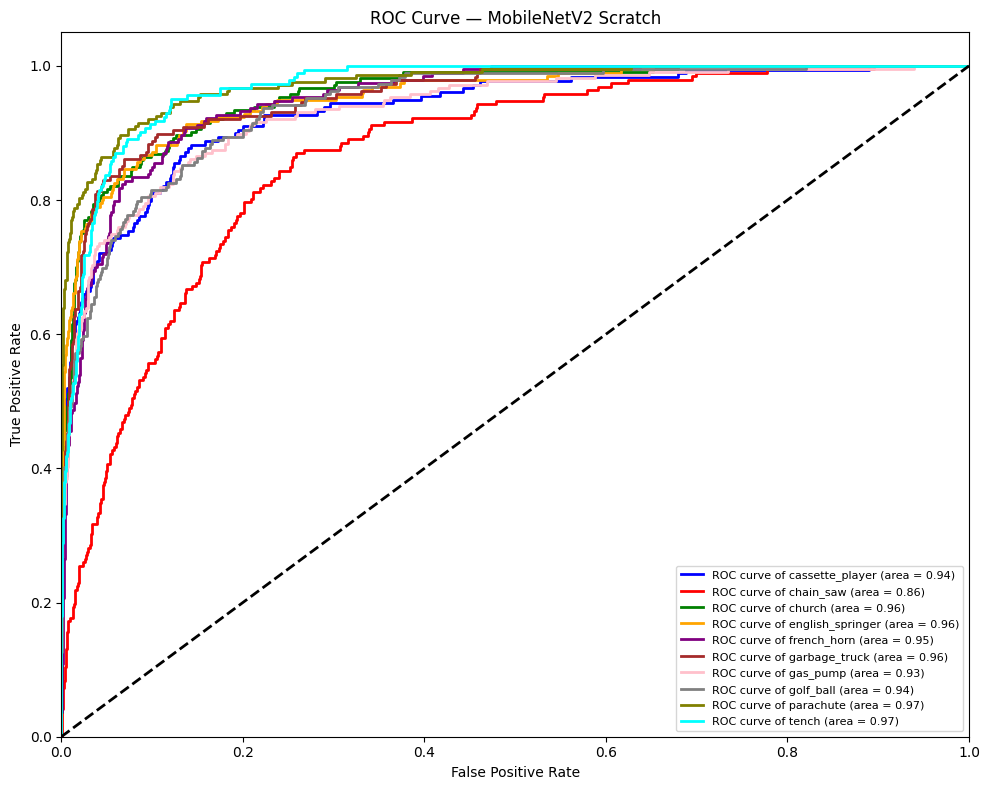

In [54]:
# MobileNetV2 Scratch - ROC AUC
y_test_mob_scratch, y_score_mob_scratch = y_probs(model_scratch_MB, dataloaders['val'])

n_classes = len(class_names)
y_bin     = label_binarize(y_test_mob_scratch, classes=[i for i in range(n_classes)])
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score_mob_scratch[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'orange', 'purple',
                'brown', 'pink', 'gray', 'olive', 'cyan'])

plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MobileNetV2 Scratch')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretation


I think the acuracy of my mobilenetv2 scratch has achieved its peak or close to it, adding more epoch from first try of 10 epoch to 25 epoch doesn't have the increase I'm expecting. The confusion matrix is almost similar to scratch vgg16, it can classify the majority but still has flase predictioin. The ROC curve  results shows that only chain_saw class is being poorly classified.

## MobileNetv2 (Pre-trained)

In [42]:
model_mbv2 = models.mobilenet_v2(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 86.5MB/s]


In [43]:
model_mbv2.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [44]:
model_mbv2.classifier[1] = nn.Linear(1280, num_classes)

In [45]:
model_mbv2 = model_mbv2.to(device)

for param in model_mbv2.features.parameters():
    param.requires_grad = False

In [46]:
criterion_mb = nn.CrossEntropyLoss()

optimizer_mb = optim.SGD(
    model_mbv2.parameters(),
    lr=0.001,
    momentum=0.9
)

exp_lr_scheduler_mb = lr_scheduler.StepLR(optimizer_mb, step_size=7, gamma=0.1)

In [47]:
model_mbv2, hist_mbv2 = train_model(model_mbv2, criterion_mb,optimizer_mb, exp_lr_scheduler_mb,
                                    num_epochs=10)

Epoch 0/9
----------


train: 100%|██████████| 148/148 [00:26<00:00,  5.51it/s, loss=0.538]


train Loss: 0.8918 Acc: 0.7740


val: 100%|██████████| 62/62 [00:12<00:00,  4.97it/s, loss=0.163]


val Loss: 0.2814 Acc: 0.9455

Epoch 1/9
----------


...

val Loss: 0.1383 Acc: 0.9633

Epoch 9/9
----------


train: 100%|██████████| 148/148 [00:27<00:00,  5.32it/s, loss=0.259]


train Loss: 0.2663 Acc: 0.9214


val: 100%|██████████| 62/62 [00:12<00:00,  4.96it/s, loss=0.17]

val Loss: 0.1383 Acc: 0.9597

Training complete in 6m 42s
Best val Acc: 0.963303


### Plotting

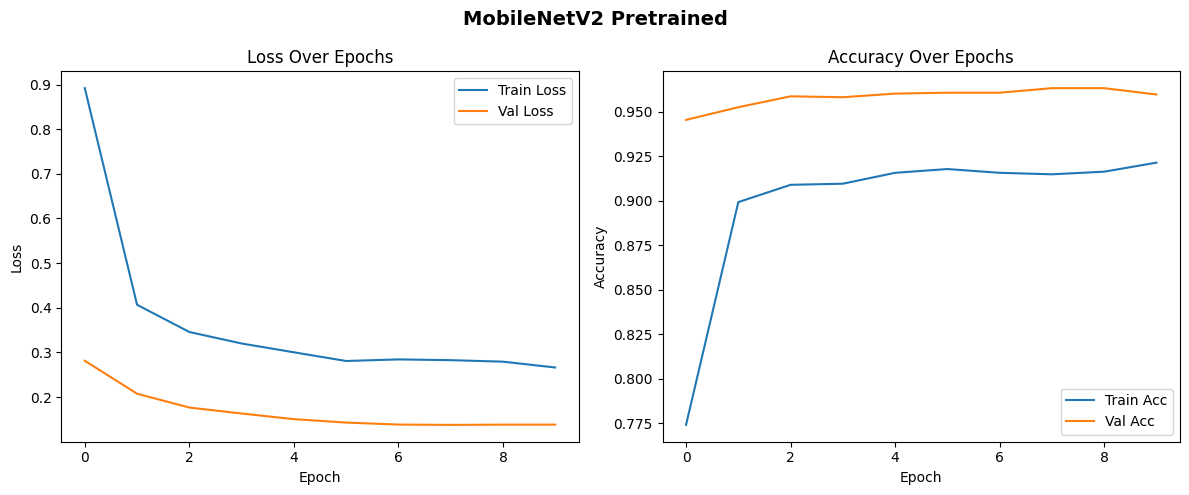

In [48]:
# MobileNetV2 Pretrained - Loss & Accuracy

plt.figure(figsize=(12, 5))
plt.suptitle('MobileNetV2 Pretrained', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 1)
plt.plot(hist_mbv2['train_loss'], label='Train Loss')
plt.plot(hist_mbv2['val_loss'],   label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_mbv2['train_acc'], label='Train Acc')
plt.plot(hist_mbv2['val_acc'],   label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report — MobileNetV2 Pretrained
(Sensitivity = Recall for each class)

                  precision    recall  f1-score   support

 cassette_player       0.96      0.96      0.96       179
       chain_saw       0.92      0.93      0.92       192
          church       0.96      0.99      0.97       213
english_springer       0.98      0.96      0.97       195
     french_horn       0.96      0.97      0.97       193
   garbage_truck       0.95      0.95      0.95       188
        gas_pump       0.98      0.93      0.95       216
       golf_ball       0.95      0.99      0.97       189
       parachute       0.97      0.98      0.97       213
           tench       0.99      0.98      0.98       184

        accuracy                           0.96      1962
       macro avg       0.96      0.96      0.96      1962
    weighted avg       0.96      0.96      0.96      1962



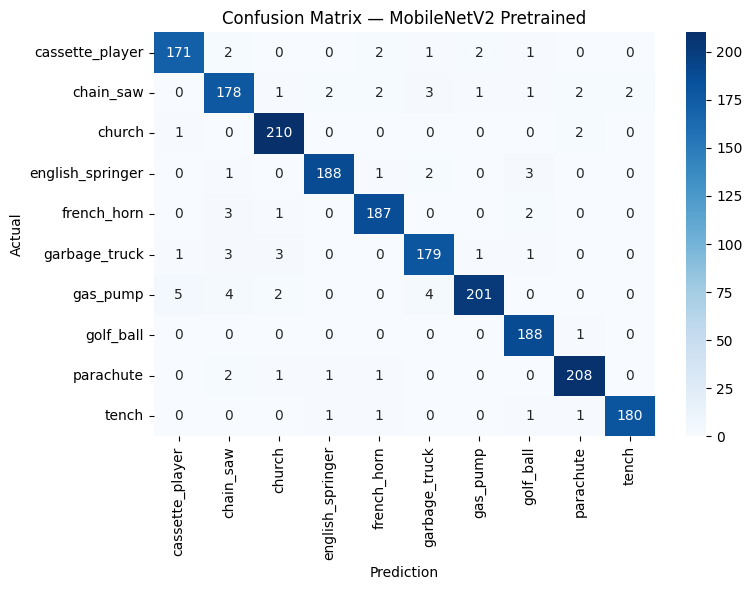

In [49]:
# MobileNetV2 Pretrained - Confusion Matrix & Classification Report

y_true_mob_pre, y_pred_mob_pre = predictions(model_mbv2, dataloaders['val'])

print("Classification Report — MobileNetV2 Pretrained")
print("(Sensitivity = Recall for each class)\n")
print(classification_report(y_true_mob_pre, y_pred_mob_pre, target_names=class_names))

cm = confusion_matrix(y_true_mob_pre, y_pred_mob_pre)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix — MobileNetV2 Pretrained')
plt.tight_layout()
plt.show()

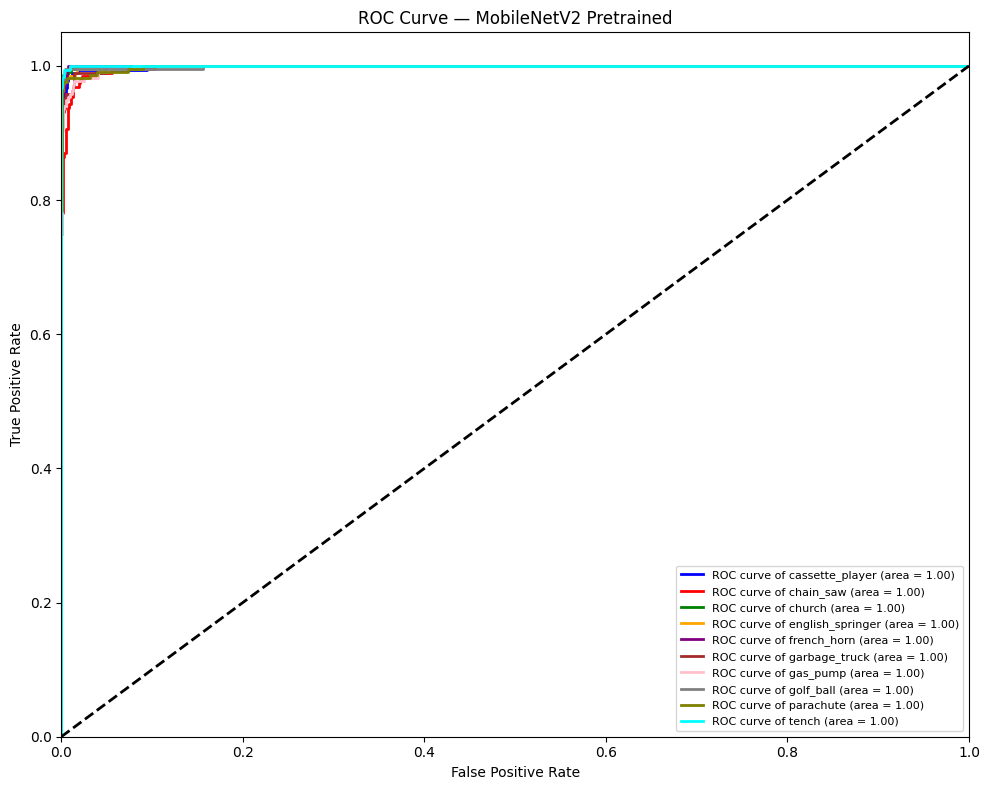

In [50]:
#  BLOCK 12 — MobileNetV2 Pretrained - ROC AUC
y_test_mob_pre, y_score_mob_pre = y_probs(model_mbv2, dataloaders['val'])

n_classes = len(class_names)
y_bin     = label_binarize(y_test_mob_pre, classes=[i for i in range(n_classes)])
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score_mob_pre[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'orange', 'purple',
                'brown', 'pink', 'gray', 'olive', 'cyan'])

plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MobileNetV2 Pretrained')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretation

Overall looks good. The pretrained mobilenetv2 model can classify all of the class in my dataset.

## Conclusion

In conclusion, I learned how to create vgg16 and mobilenetv2 architecture from scratch. It's a cool and nice experience to have, but not ideal. Pretrained models are already there and has high accuracy. Training it from scratch is such a hassle and time consuming. It burns out all of my computing units yet it's accuracy didn't come close to the pretrained model even with low epochs. Overall, this activity is great to actually know the process of how the model works and what layers do they have in order to work.